# Notebook 1: Exploratory Data Analysis & Preprocessing Pipeline
## AuraCart Retail Analytics — ITS 2140 Machine Learning Group Project

Perform comprehensive EDA on the e-commerce dataset and build a reusable Scikit-learn preprocessing pipeline.

---

## 1.1 Install & Import Libraries

We use `datasets` to load the HuggingFace-hosted dataset directly, `pandas` and `numpy` for data manipulation, `matplotlib` and `seaborn` for statistical visualization, and `scikit-learn` to create a preprocessing pipeline which we will use for training and evaluation and deployment.

In [3]:
# Install required packages (run once)
!pip install datasets pandas numpy matplotlib seaborn scikit-learn joblib imbalanced-learn -q

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import joblib

from datasets import load_dataset
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.figsize'] = (10, 5)

os.makedirs('../artifacts', exist_ok=True)
print("Libraries loaded successfully!")

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Libraries loaded successfully!


---
## 1.2 Load Dataset from HuggingFace

The dataset is the **"E-commerce Customer Order Behavior Dataset"** by Millat, hosted on the HuggingFace Hub.
The collection contains **10,000 separate transaction records** which represent the data types that AuraCart handles during its everyday operations.
We load it through our programming methods because this approach enables complete reproducibility without needing any manual file download procedures.

In [5]:
# Load the dataset from HuggingFace Hub
print("Loading dataset from HuggingFace...")
dataset = load_dataset("millat/e-commerce-orders")
df = dataset['train'].to_pandas()

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Loading dataset from HuggingFace...


Dataset loaded: 10,000 rows × 15 columns


,order_id,customer_id,product_id,category,price,quantity,order_date,shipping_date,delivery_status,payment_method,device_type,channel,shipping_address,billing_address,customer_segment
0,b8ec9f86-5919-4b71-a5f7-945e7c0a3db0,2031,845,Books,45.95,4,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,PayPal,Mobile,Paid Search,"976 Kevin Station, Davidmouth, Hawaii 92563","38182 Ariel Expressway, Campbellland, Oklahoma...",VIP
1,5ea92c47-c5b2-4bdd-8a50-d77efd77ec89,2350,995,Electronics,403.17,3,2024-04-20 14:59:58.897063,2024-04-22 14:59:58.897063,Delivered,PayPal,Mobile,Paid Search,"72166 Cunningham Crescent, East Nicholasside, ...","38199 Edwin Plain, Johnborough, Maine 81826",Returning
2,5cc48ce0-2c6d-4448-af3f-96f8a910d45b,1818,997,Beauty,317.45,2,2024-04-20 14:59:58.897063,2024-04-27 14:59:58.897063,Shipped,Credit Card,Mobile,Email,"2446 Johnson Junctions, Lynchtown, Minnesota 7...","58086 Smith Stream Suite 994, Lake Pamelabury,...",Returning
3,74d5c0f4-53f0-4367-a5c5-baaa114c2d9f,472,385,Home,24.08,3,2024-04-20 14:59:58.897063,2024-04-24 14:59:58.897063,Shipped,PayPal,Tablet,Social,"3113 Jessica Knolls, North Joshuafort, Alabama...","484 Palmer Harbors Apt. 866, Dustintown, Nebra...",VIP
4,7a630323-8ac8-406e-875a-4bcdead440ab,1075,31,Clothing,494.90,1,2024-04-20 14:59:58.897063,2024-04-25 14:59:58.897063,Delivered,PayPal,Tablet,Organic,"58196 Burgess Heights Suite 315, Douglasland, ...","67094 Schaefer Villages Suite 369, Douglasches...",VIP


---
## 1.3 Initial Data Inspection

Before we proceed with modeling work, we need to examine the dataset structure which includes column types and missing values and duplicate rows together with basic statistics. The preprocessing requirements will be established through this process which determines whether any data quality problems need resolution before the training phase.

In [6]:
# Shape and data types
print("=" * 50)
print(f"Shape: {df.shape}")
print("=" * 50)
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDuplicate Rows:", df.duplicated().sum())

Shape: (10000, 15)

Data Types:
order_id             object
customer_id           int64
product_id            int64
category             object
price               float64
quantity              int64
order_date           object
shipping_date        object
delivery_status      object
payment_method       object
device_type          object
channel              object
shipping_address     object
billing_address      object
customer_segment     object
dtype: object

Missing Values:
order_id            0
customer_id         0
product_id          0
category            0
price               0
quantity            0
order_date          0
shipping_date       0
delivery_status     0
payment_method      0
device_type         0
channel             0
shipping_address    0
billing_address     0
customer_segment    0
dtype: int64

Duplicate Rows: 0


In [7]:
# Basic descriptive statistics
print("Descriptive Statistics for Numeric Columns:")
df.describe()

Descriptive Statistics for Numeric Columns:


,customer_id,product_id,price,quantity
count,10000.000000,10000.000000,10000.000000,10000.000000
mean,995.292300,504.872400,252.550681,2.124700
std,893.279854,288.281942,141.394146,1.254315
min,1.000000,1.000000,5.060000,1.000000
25%,182.000000,260.000000,130.607500,1.000000
50%,754.000000,507.000000,252.910000,2.000000
75%,1668.500000,752.000000,374.917500,3.000000
max,2999.000000,1000.000000,499.930000,9.000000


---
## 1.4 Feature Engineering from Date Columns

Machine learning models cannot use raw datetime columns because they contain non-numeric data which has infinite possible values. 
We extract useful numeric components which enable us to capture seasonal and temporal patterns through our analysis. 

- **order_month**: The order_month metric shows seasonal buying patterns which include holiday spikes that occur in December.
- **order_day**: The day of the month might show a link to customer spending patterns which occur on paydays.
- **order_hour**: People use their devices more during certain hours of the day which increases their chances of making impulse purchases.
- **order_dayofweek**: People show different shopping habits on weekends compared to weekdays.
- **shipping_delay_days**: The shipping delay days represent the interval between shipping and order dates which serves as a strong predictor of delivery outcomes.

The analysis removes ID columns which include order_id customer_id and product_id together with free-text address fields which include shipping_address and billing_address because these elements do not provide useful information for making predictions.

In [8]:
# Parse datetime columns
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')
df['shipping_date'] = pd.to_datetime(df['shipping_date'], errors='coerce')

# Extract temporal features from order_date
df['order_month'] = df['order_date'].dt.month
df['order_day']   = df['order_date'].dt.day
df['order_hour']  = df['order_date'].dt.hour
df['order_dayofweek'] = df['order_date'].dt.dayofweek  # 0=Monday

# Compute shipping delay in days
df['shipping_delay_days'] = (df['shipping_date'] - df['order_date']).dt.days

# Drop original datetime columns and ID/address columns
cols_to_drop = ['order_id', 'customer_id', 'product_id',
                'order_date', 'shipping_date',
                'shipping_address', 'billing_address']
df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)

print("Feature engineering complete. Remaining columns:")
print(df.columns.tolist())
df.head(3)

Feature engineering complete. Remaining columns:
['category', 'price', 'quantity', 'delivery_status', 'payment_method', 'device_type', 'channel', 'customer_segment', 'order_month', 'order_day', 'order_hour', 'order_dayofweek', 'shipping_delay_days']


,category,price,quantity,delivery_status,payment_method,device_type,channel,customer_segment,order_month,order_day,order_hour,order_dayofweek,shipping_delay_days
0,Books,45.95,4,Shipped,PayPal,Mobile,Paid Search,VIP,4,20,14,5,7
1,Electronics,403.17,3,Delivered,PayPal,Mobile,Paid Search,Returning,4,20,14,5,2
2,Beauty,317.45,2,Shipped,Credit Card,Mobile,Email,Returning,4,20,14,5,7


---
## 1.5 EDA — Continuous Variable Analysis

The study investigates how `price` distribution behaves as the **regression target** through three different analytical methods. The **Histogram** displays the complete distribution pattern which shows three distinct distribution shapes of uniform distribution and normal distribution and skewed distribution. The **KDE (Kernel Density Estimate)** provides a continuous probability density function through its smoothed approximation. The **Boxplot** displays outlier data points while showing the intervals between quartiles and the location of the median. The target distribution requires comprehension because a **uniform** distribution indicates that price operates as a random variable which depends on the provided features which results in challenging regression work. The distribution requires log-transformation for modeling according to its **skewed** characteristics.

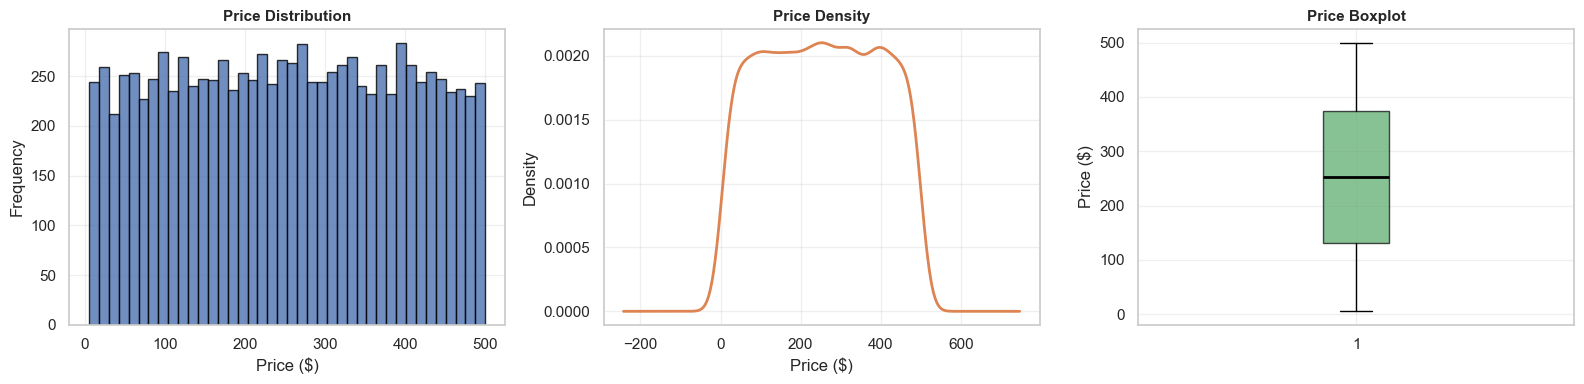

Price Stats → Mean: $252.55 | Std: $141.39 | Skewness: -0.004


In [20]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Histogram
axes[0].hist(df['price'], bins=40, color='#4C72B0', edgecolor='black', alpha=0.8)
axes[0].set_title('Price Distribution', fontsize=11, weight='bold')
axes[0].set_xlabel('Price ($)')
axes[0].set_ylabel('Frequency')
axes[0].grid(alpha=0.3)

# KDE plot
df['price'].plot(kind='kde', ax=axes[1], color='#DD8452', linewidth=2)
axes[1].set_title('Price Density', fontsize=11, weight='bold')
axes[1].set_xlabel('Price ($)')
axes[1].grid(alpha=0.3)

# Boxplot
axes[2].boxplot(
    df['price'].dropna(),
    vert=True,
    patch_artist=True,
    boxprops=dict(facecolor='#55A868', alpha=0.7),
    medianprops=dict(color='black', linewidth=2)
)
axes[2].set_title('Price Boxplot', fontsize=11, weight='bold')
axes[2].set_ylabel('Price ($)')
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/eda_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Price Stats → Mean: ${df['price'].mean():.2f} | "
      f"Std: ${df['price'].std():.2f} | "
      f"Skewness: {df['price'].skew():.3f}")

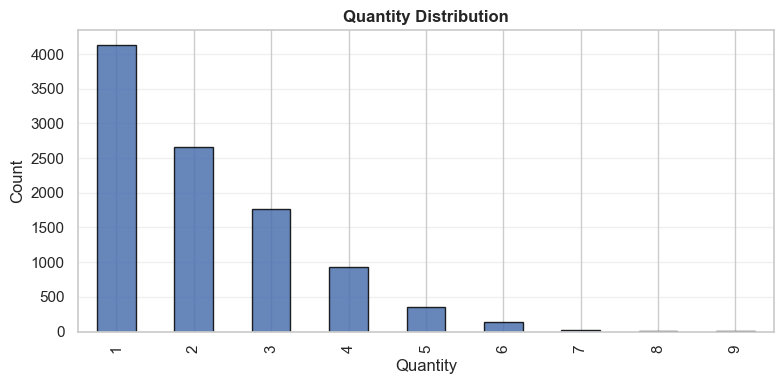

In [21]:
# Quantity distribution
fig, ax = plt.subplots(figsize=(8, 4))

df['quantity'].value_counts().sort_index().plot(
    kind='bar',
    ax=ax,
    color='#4C72B0',
    edgecolor='black',
    alpha=0.85
)

ax.set_title('Quantity Distribution', fontsize=12, weight='bold')
ax.set_xlabel('Quantity')
ax.set_ylabel('Count')

# Grid for better readability
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/eda_quantity_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 1.6 EDA — Categorical Variable Analysis

We create visual representations of class distributions which apply to the two classification targets of `delivery_status` and `customer_segment` testing. 

This step is crucial because **class imbalance** is a known challenge in this dataset:
- **Delivery Status:** ~70% Delivered, ~20% Shipped, ~5% Pending, ~5% Returned
- **Customer Segment:** ~50% New, ~35% Returning, ~15% VIP

A naïve classifier achieves high accuracy through majority class predictions when the data imbalance reaches extreme levels. The modelling phase requires us to implement **SMOTE** and **class_weight='balanced'** and **stratified cross-validation** as strategies.

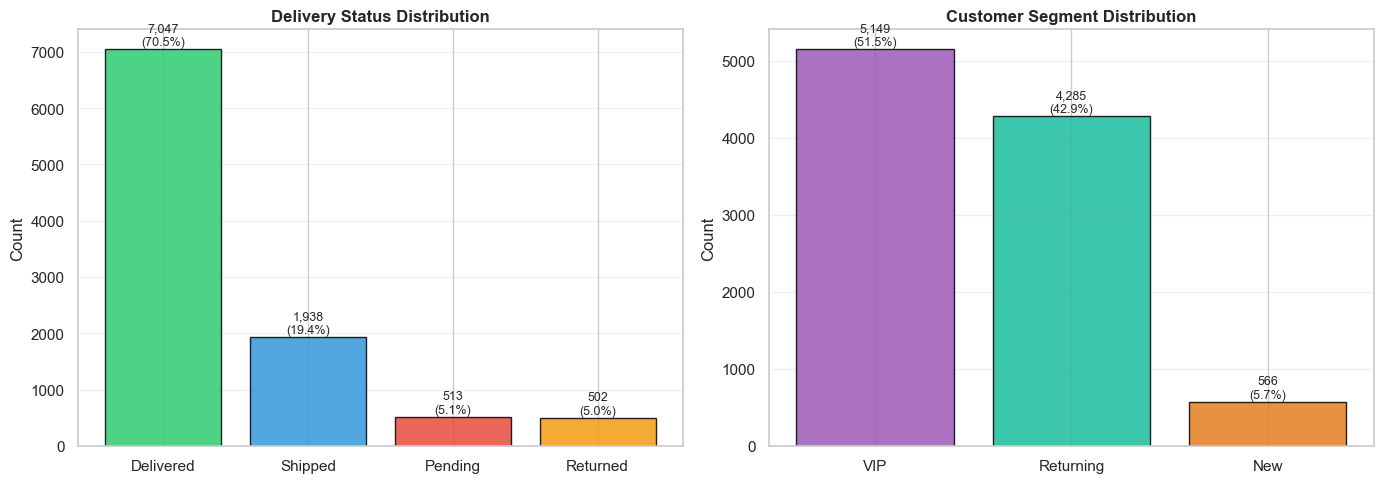


--- DELIVERY STATUS ---
delivery_status
Delivered    7047
Shipped      1938
Pending       513
Returned      502
Name: count, dtype: int64

--- CUSTOMER SEGMENT ---
customer_segment
VIP          5149
Returning    4285
New           566
Name: count, dtype: int64


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Delivery Status distribution
ds_counts = df['delivery_status'].value_counts()
axes[0].bar(
    ds_counts.index,
    ds_counts.values,
    color=['#2ecc71', '#3498db', '#e74c3c', '#f39c12'],
    edgecolor='black',
    alpha=0.85
)
axes[0].set_title('Delivery Status Distribution', fontsize=12, weight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(axis='y', alpha=0.3)

for i, v in enumerate(ds_counts.values):
    axes[0].text(
        i, v + max(ds_counts.values)*0.01,
        f'{v:,}\n({v/len(df)*100:.1f}%)',
        ha='center',
        fontsize=9
    )

# Customer Segment distribution
cs_counts = df['customer_segment'].value_counts()
axes[1].bar(
    cs_counts.index,
    cs_counts.values,
    color=['#9b59b6', '#1abc9c', '#e67e22'],
    edgecolor='black',
    alpha=0.85
)
axes[1].set_title('Customer Segment Distribution', fontsize=12, weight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(axis='y', alpha=0.3)

for i, v in enumerate(cs_counts.values):
    axes[1].text(
        i, v + max(cs_counts.values)*0.01,
        f'{v:,}\n({v/len(df)*100:.1f}%)',
        ha='center',
        fontsize=9
    )

plt.tight_layout()
plt.savefig('../artifacts/eda_class_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n--- DELIVERY STATUS ---")
print(ds_counts)
print("\n--- CUSTOMER SEGMENT ---")
print(cs_counts)

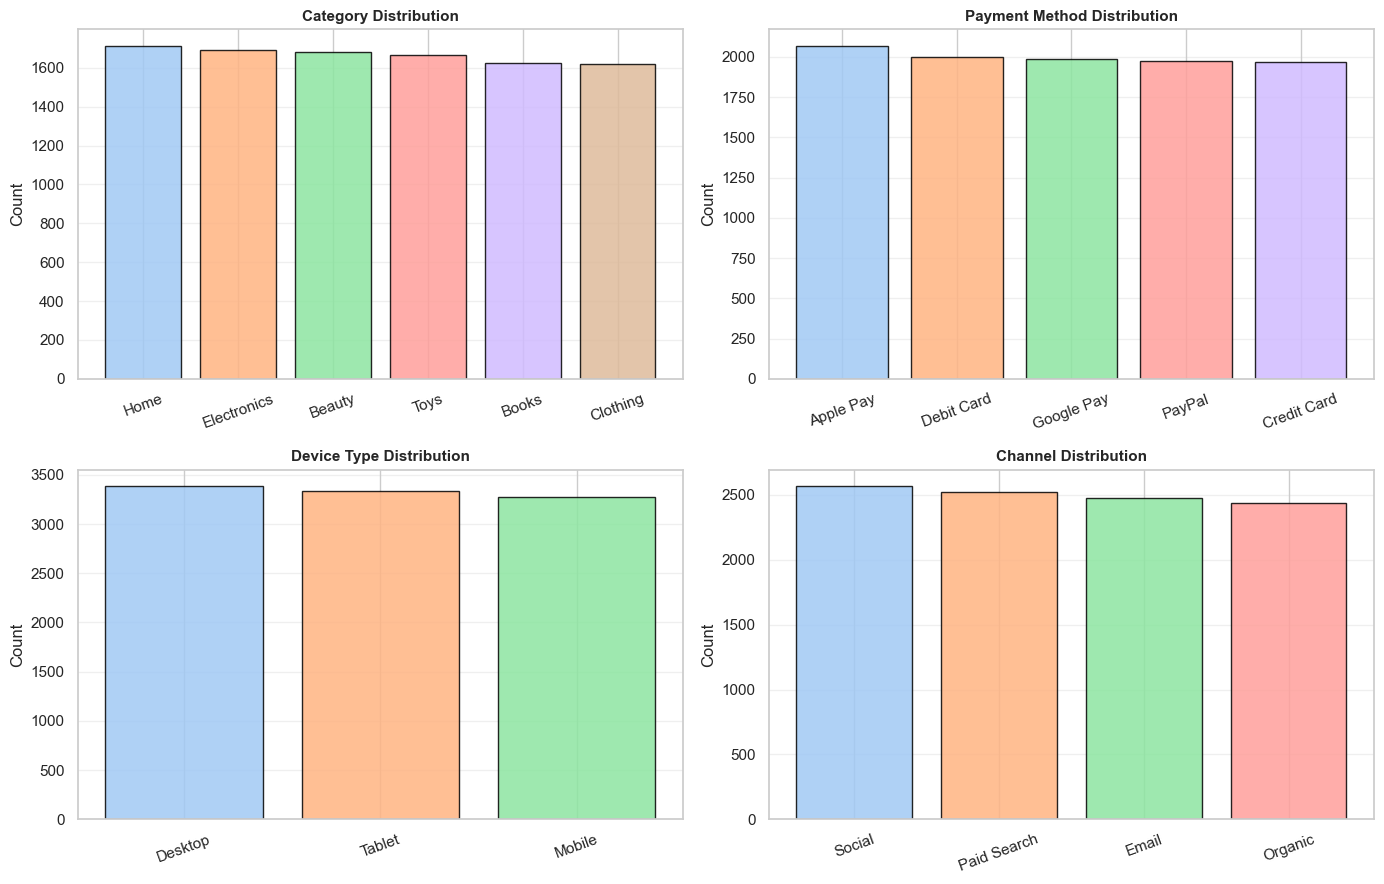

In [24]:
# Other categorical features
cat_cols = ['category', 'payment_method', 'device_type', 'channel']

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()

    axes[i].bar(
        counts.index,
        counts.values,
        color=sns.color_palette('pastel'),
        edgecolor='black',
        alpha=0.85
    )

    axes[i].set_title(f'{col.replace("_", " ").title()} Distribution', fontsize=11, weight='bold')
    axes[i].set_ylabel('Count')

    axes[i].tick_params(axis='x', rotation=20)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../artifacts/eda_categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 1.7 EDA — Correlation Analysis

The study uses the Pearson correlation matrix to analyze how numeric features relate to each other through linear connections. 

**Why Pearson?** It is the standard measure for continuous-to-continuous linear association. We chose Pearson over Spearman because our numeric features (quantity, extracted date components, shipping delay) do not exhibit obviously non-linear monotonic relationships that would make Spearman more appropriate.

**Why does this matter?** Multicollinearity causes high inter-feature correlation between multiple features which leads to increased regression coefficient variance and resulting model instability. The presence of high feature correlation between two features with |r| values exceeding 0.7 requires us to evaluate which feature should be removed to enhance the model's understanding. The target relationships show low correlation with features because this pattern indicates that a linear model will face difficulties in establishing the connection between them.

Numeric columns used for correlation: ['price', 'quantity', 'order_month', 'order_day', 'order_hour', 'order_dayofweek', 'shipping_delay_days']


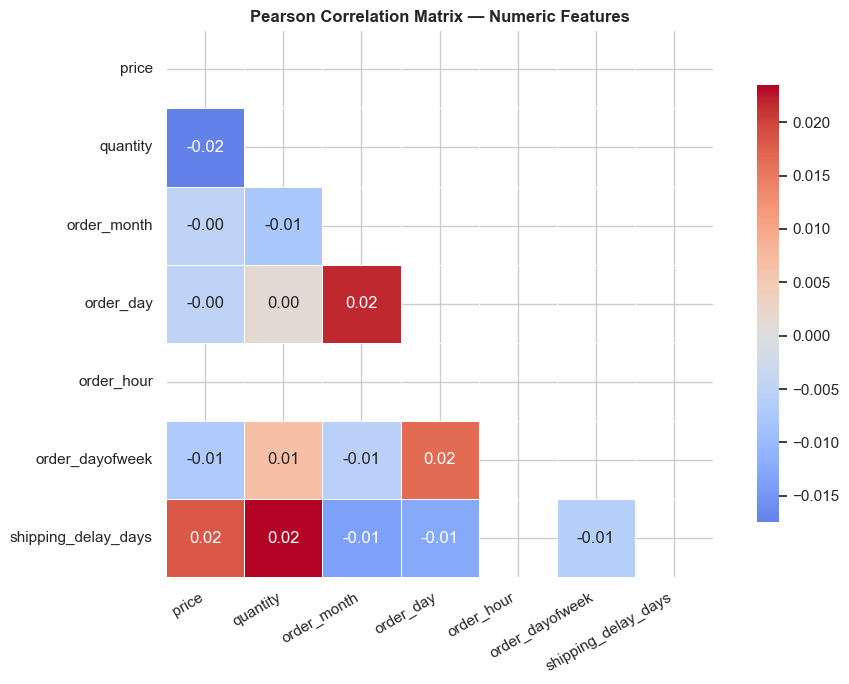


No strong correlations found (|r| > 0.5). Features are largely independent.


In [25]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print("Numeric columns used for correlation:", numeric_cols)

corr_matrix = df[numeric_cols].corr(method='pearson')

plt.figure(figsize=(10, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'shrink': 0.8},
    square=True
)

plt.title('Pearson Correlation Matrix — Numeric Features', fontsize=12, weight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.savefig('../artifacts/eda_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Highlight strong correlations (|r| > 0.5)
strong = [(c1, c2, corr_matrix.loc[c1, c2])
          for c1 in corr_matrix.columns
          for c2 in corr_matrix.columns
          if c1 < c2 and abs(corr_matrix.loc[c1, c2]) > 0.5]

if strong:
    print("\nStrong correlations (|r| > 0.5):")
    for c1, c2, r in strong:
        print(f"  {c1} ↔ {c2}: r = {r:.3f}")
else:
    print("\nNo strong correlations found (|r| > 0.5). Features are largely independent.")

---
## 1.8 Key EDA Findings Summary

| Finding | Observation | Impact on Modeling | Action Taken |
|---|---|---|---|
| Price distribution | Approximately uniform ($5–$500), low skewness | Linear regression will have very limited explanatory power (expect near-zero R²) | Apply StandardScaler; document expected underfitting |
| Delivery status imbalance | ~70% Delivered, ~5% each for Pending/Returned | Naïve classifier would achieve ~70% accuracy by always predicting 'Delivered' | Apply SMOTE + class_weight='balanced'; evaluate with F1/recall, not accuracy |
| Customer segment imbalance | ~15% VIP (the most valuable cohort to identify) | Poor VIP recall has the highest business cost | Stratified splits + per-class metric analysis |
| Date columns | Raw datetimes are non-numeric | Cannot be fed directly to models | Extracted month, day, hour, dayofweek, shipping_delay |
| Inter-feature correlation | Low correlation (all |r| < 0.5) | No multicollinearity issues; all features are largely independent | All features retained; no dimensionality reduction needed |
| Outliers in price | Boxplot shows no extreme outliers (uniform distribution has no natural outliers) | No need for winsorization or clipping | Features used as-is after scaling |

**Key Insight:** The approximately uniform price distribution and low inter-feature correlations demonstrate that price in this dataset exists as an independent variable from all behavioral features. The statement is true because real e-commerce systems determine product prices through product characteristics instead of buyer device and channel selection. We will conduct the regression task for our project requirements and present all expected underfitting results in Notebook 2.

---
## 1.9 Build Scikit-learn Preprocessing Pipeline

The entire process of preprocessing is executed through one unified system which we refer to as `ColumnTransformer` pipeline. This approach represents essential industry standard which data scientists should follow when they work on machine learning projects for operational environments.

**Why a Pipeline?**
- **Reproducibility**: The exact same transformations are applied during training, validation, and deployment.
- **No data leakage**: Fitting and transforming happen together, preventing test-set statistics from leaking into training.
- **Deployment compatibility**: Vertex AI's pre-built container calls `pipeline.predict(X)` on raw input, so the pipeline must encapsulate all preprocessing.

**Design Decisions:**
- **Numeric pipeline:** `SimpleImputer(strategy='median')` → `StandardScaler()`
  - *Median imputation* is robust to outliers (unlike mean imputation).
  - *StandardScaler* (z-score normalization) centers features at zero with unit variance, which is essential for gradient-descent-based models like SGDRegressor and LogisticRegression.
- **Categorical pipeline:** `SimpleImputer(strategy='most_frequent')` → `OneHotEncoder(handle_unknown='ignore')`
  - *One-hot encoding* is appropriate because our categorical features (category, payment_method, device_type, channel) are **nominal** — they have no inherent order.
  - `handle_unknown='ignore'` ensures the pipeline doesn't crash if a new category appears at prediction time.
- **`remainder='drop'** will eliminate all features which have not been specifically defined in the system while only permitting defined features to proceed.

In [14]:
# Define feature groups
numeric_features = ['quantity', 'order_month', 'order_day', 'order_hour',
                    'order_dayofweek', 'shipping_delay_days']

categorical_features = ['category', 'payment_method', 'device_type', 'channel']

# Numeric pipeline: impute missing values → scale
numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Categorical pipeline: impute missing → one-hot encode
categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Combine into ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline,      numeric_features),
    ('cat', categorical_pipeline,  categorical_features)
], remainder='drop')

print("Preprocessing pipeline defined successfully!")
print("\nNumeric features:", numeric_features)
print("Categorical features:", categorical_features)

Preprocessing pipeline defined successfully!

Numeric features: ['quantity', 'order_month', 'order_day', 'order_hour', 'order_dayofweek', 'shipping_delay_days']
Categorical features: ['category', 'payment_method', 'device_type', 'channel']


In [15]:
# Fit the preprocessor on the full dataset (excluding target columns)
# We keep price, delivery_status, customer_segment as separate targets
target_cols = ['price', 'delivery_status', 'customer_segment']

X = df.drop(columns=target_cols, errors='ignore')
y_price    = df['price']
y_delivery = df['delivery_status']
y_segment  = df['customer_segment']

# Fit preprocessor
preprocessor.fit(X)
X_transformed = preprocessor.transform(X)

print(f"Original X shape:     {X.shape}")
print(f"Transformed X shape:  {X_transformed.shape}")
print(f"\nFeature matrix ready for modeling.")

Original X shape:     (10000, 10)
Transformed X shape:  (10000, 24)

Feature matrix ready for modeling.


In [16]:
# Encode classification targets
le_delivery = LabelEncoder()
le_segment  = LabelEncoder()

y_delivery_encoded = le_delivery.fit_transform(y_delivery)
y_segment_encoded  = le_segment.fit_transform(y_segment)

print("Delivery Status Classes:", le_delivery.classes_)
print("Customer Segment Classes:", le_segment.classes_)

Delivery Status Classes: ['Delivered' 'Pending' 'Returned' 'Shipped']
Customer Segment Classes: ['New' 'Returning' 'VIP']


---
## 1.10 Save Artifacts

In [17]:
# Save preprocessor pipeline
joblib.dump(preprocessor, '../artifacts/preprocessor.joblib')

# Save label encoders
joblib.dump(le_delivery, '../artifacts/le_delivery.joblib')
joblib.dump(le_segment,  '../artifacts/le_segment.joblib')

# Save cleaned dataframe for downstream notebooks
df.to_csv('../artifacts/cleaned_data.csv', index=False)

print("Artifacts saved:")
print("  ✓ ../artifacts/preprocessor.joblib")
print("  ✓ ../artifacts/le_delivery.joblib")
print("  ✓ ../artifacts/le_segment.joblib")
print("  ✓ ../artifacts/cleaned_data.csv")

Artifacts saved:
  ✓ ../artifacts/preprocessor.joblib
  ✓ ../artifacts/le_delivery.joblib
  ✓ ../artifacts/le_segment.joblib
  ✓ ../artifacts/cleaned_data.csv
